# Puell Multiple Calculator

## Formula
$$\text{Puell Multiple} = \frac{\text{Daily Coin Issuance Value (USD)}}{\text{365-Day Moving Average of Daily Issuance Value (USD)}}$$


In [1]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

/Users/tobiasmanwaring/Documents/UCL/Repos/Other/trTesting/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def get_bitcoin_price():
    """Get current Bitcoin price in USD from CoinGecko"""
    url = "https://api.coingecko.com/api/v3/simple/price"
    params = {'ids': 'bitcoin', 'vs_currencies': 'usd'}
    
    try:
        response = requests.get(url, params=params)
        if response.status_code == 200:
            return response.json()['bitcoin']['usd']
    except Exception as e:
        print(f"Error fetching price: {e}")
    return None

btc_price = get_bitcoin_price()
if btc_price:
    print(f"Current Bitcoin Price: ${btc_price:,.2f}")

Current Bitcoin Price: $68,800.00


In [3]:
def get_historical_issuance(days=365):
    """Get historical daily block rewards from Blockchain.com"""
    url = "https://api.blockchain.info/charts/miners-revenue"
    params = {
        'timespan': f'{days}days',
        'format': 'json',
        'sampled': 'false'
    }

    print(f"Fetching {days} days of historical data...")
    response = requests.get(url, params=params)
        
    if response.status_code == 200:
        data = response.json()
        df = pd.DataFrame(data['values'])
        df['date'] = pd.to_datetime(df['x'], unit='s')
        df['revenue_usd'] = df['y']
        df = df[['date', 'revenue_usd']]
        return df

historical_data = get_historical_issuance(days=365)

display(historical_data.head())

Fetching 365 days of historical data...


,date,revenue_usd
0,2025-02-07,5.621735e+07
1,2025-02-08,4.861195e+07
2,2025-02-09,4.351793e+07
3,2025-02-10,4.332070e+07
4,2025-02-11,3.886164e+07


In [4]:
def calculate_puell_multiple(daily_issuance_usd, historical_df):
    avg_365_days = historical_df['revenue_usd'].mean()
    puell_multiple = daily_issuance_usd / avg_365_days
    
    return puell_multiple, avg_365_days

if historical_data is not None:
    today_issuance = historical_data['revenue_usd'].iloc[-1]
    today_date = historical_data['date'].iloc[-1]
    
    puell, avg_365 = calculate_puell_multiple(today_issuance, historical_data)
    
    print(f"Date: {today_date.strftime('%Y-%m-%d')}")
    print(f"Today mining revenue: ${today_issuance:,.2f}")
    print(f"365 average revenue: ${avg_365:,.2f}")
    print(f"\nPUELL MULTIPLE: {puell:.3f}")

Date: 2026-02-06
Today mining revenue: $31,304,063.41
365 average revenue: $46,932,617.36

PUELL MULTIPLE: 0.667


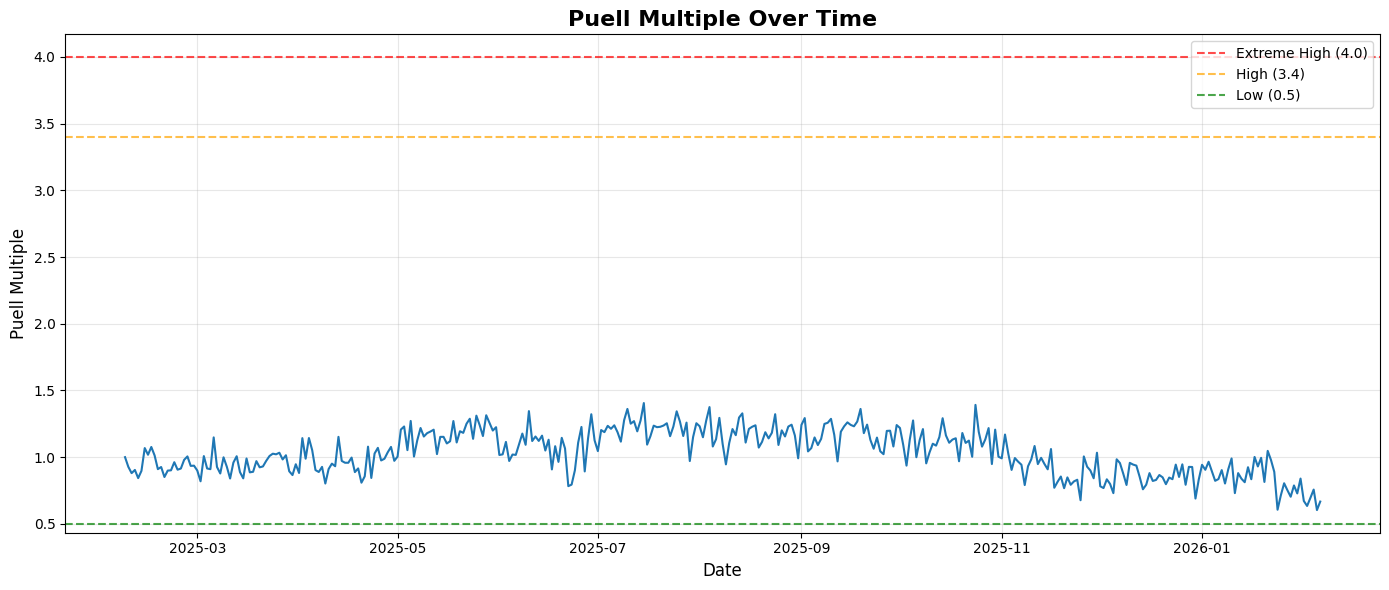


Statistical Summary:
Mean: 1.032
Median: 1.020
Min: 0.603
Max: 1.405


In [5]:
import matplotlib.pyplot as plt

if historical_data is not None:
    historical_data['ma_365'] = historical_data['revenue_usd'].rolling(window=365, min_periods=1).mean()
    historical_data['puell_multiple'] = historical_data['revenue_usd'] / historical_data['ma_365']
    
    plt.figure(figsize=(14, 6))
    plt.plot(historical_data['date'], historical_data['puell_multiple'], linewidth=1.5)
    
    plt.axhline(y=4.0, color='red', linestyle='--', alpha=0.7, label='Extreme High (4.0)')
    plt.axhline(y=3.4, color='orange', linestyle='--', alpha=0.7, label='High (3.4)')
    plt.axhline(y=0.5, color='green', linestyle='--', alpha=0.7, label='Low (0.5)')
    
    plt.title('Puell Multiple Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Puell Multiple', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nStatistical Summary:")
    print(f"Mean: {historical_data['puell_multiple'].mean():.3f}")
    print(f"Median: {historical_data['puell_multiple'].median():.3f}")
    print(f"Min: {historical_data['puell_multiple'].min():.3f}")
    print(f"Max: {historical_data['puell_multiple'].max():.3f}")